In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin-1')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [16]:

df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping_Days,Discount_Amount,avg_shipping_days_per_region
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,32.277580,3.958175
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,0.000000,3.908708
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,0.000000,3.908708
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,1.036800,3.929753
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,14.870400,3.958025
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,11319.240000,4.058115
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,164.025577,0.057255


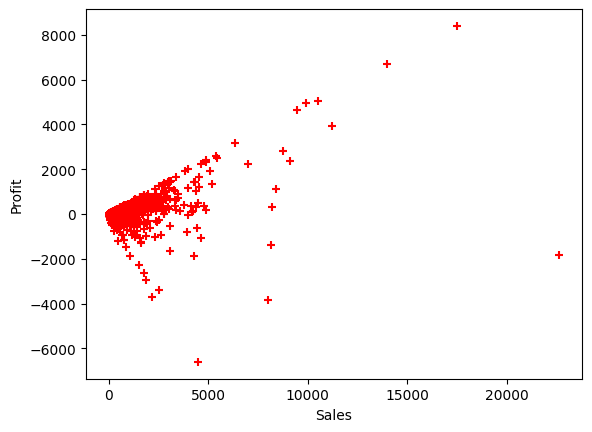

In [17]:
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.scatter(df.Sales,df['Profit'],color='red',marker='+')

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date','Ship Date','Shipping_Days']].head()

,Order Date,Ship Date,Shipping_Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [9]:
df['Discount_Amount'] = (df['Sales'] * df['Discount'])
df[['Sales','Discount','Discount_Amount']].head()

,Sales,Discount,Discount_Amount
0,261.9600,0.00,0.000000
1,731.9400,0.00,0.000000
2,14.6200,0.00,0.000000
3,957.5775,0.45,430.909875
4,22.3680,0.20,4.473600


In [10]:
df['avg_shipping_days_per_region'] = df.groupby('Region')['Shipping_Days'].transform('mean')
df[['Region','Shipping_Days','avg_shipping_days_per_region']].head()

,Region,Shipping_Days,avg_shipping_days_per_region
0,South,3,3.958025
1,South,3,3.958025
2,West,4,3.929753
3,South,7,3.958025
4,South,7,3.958025


In [11]:
X = df[['Sales',
        'Quantity',
        'Discount',
        'Shipping_Days',
        'Discount_Amount',
        'avg_shipping_days_per_region']]
y = df['Profit']


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()


In [20]:
model.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
print("R² Score:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

R² Score: 0.31634414058336635
Accuracy Percentage: 31.634414058336635


In [29]:
from sklearn import linear_model
lasso_reg = linear_model.Lasso(alpha=50, max_iter=100, tol=0.1)
lasso_reg.fit(X_train, y_train)

Lasso(alpha=50, max_iter=100, tol=0.1)

In [30]:
lasso_reg.score(X_test, y_test)

0.3161799167396926

In [31]:
lasso_reg.score(X_train, y_train)

0.7720593694373846

In [38]:
new_data = pd.DataFrame({
    'Sales': [2500],
    'Quantity': [5],
    'Discount': [0.10],
    'Shipping_Days': [3],
    'Discount_Amount': [500 * 0.10],
    'avg_shipping_days_per_region': [4]
})

prediction = model.predict(new_data)

print("Predicted Profit:", prediction[0])

Predicted Profit: 919.5599228471372


In [36]:
model.predict([[500, 5, 0.10, 3, 500*0.10, 4]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([105.2254113])